We will run an experiment to find the expected number of fair coin tosses to get n consecutive heads. We do this by simulating the experiment 100000 times.

In [38]:
import random

def Expectation_nH(n, N= 100000):

  s = ['H', 'T']
  total = 0

  for _ in range(N):
    toss = 0
    heads = 0
    while heads < n:
      toss += 1
      if random.choice(s) == 'H':
        heads += 1
      else:
        heads = 0

    total += toss

  result = total / N

  return result


We run our experiment to find the expected number of tosses until we get 3 consecutive heads.

In [39]:
e = Expectation_nH(3)

print(f"Expected number of tosses to get 3 consecutive heads is: {e}")

Expected number of tosses to get 3 consecutive heads is: 14.08014


Our result is approximately equals to the theoritical expectation, that is 14.

We use monte carlo to estimate the value of $\pi$.

In [40]:
import numpy as np

In [41]:
def Estimate_pi(N = 100000):
  x = np.random.uniform(0, 1, N)
  y = np.random.uniform(0, 1, N)

  z = np.sqrt(np.square(x) + np.square(y))
  r = z[z<=1]

  result = r.size/N
  return result


In [42]:
pi = Estimate_pi()

print(f"The estimated value of pi is : {4 * pi}")

The estimated value of pi is : 3.14192


Pricing European option using monte carlo

In [43]:
r = 0.045
K = 110
sigma = 0.35
T = 1
T_0 = 0.5
S_0 = 100

In [44]:
def GBM(S_0, r, T, sigma, no_paths= 100):

  no_steps = 100
  dt = T/no_steps

  np.random.seed(10)

  Z = np.random.normal(0, 1, [no_paths, no_steps])
  X = np.zeros([no_paths, no_steps + 1])
  # S = np.zeros([no_paths, no_steps + 1])
  time = np.zeros([no_steps + 1])

  X[:, 0] = np.log(S_0)

  for i in range(no_steps):
    if no_paths > 1:
      Z[:, i] = (Z[:, i] - np.mean(Z[:, i])) / np.std(Z[:, i])
    X[:, i + 1] = X[:, i] + (r - 0.5 * np.square(sigma)) * dt + sigma * np.sqrt(dt) * Z[:, i]
    time[i + 1] = time[i] + dt

  S = np.exp(X)

  paths = {'time': time, 'X': X, 'S': S}

  return paths

In [45]:
paths = GBM(S_0, r, T, sigma)

In [46]:
# half_idx = np.searchsorted(paths['time'], 0.5, side='right')

In [47]:
# paths_6m = {
#     'time': paths['time'][:half_idx],      # shape: (51,)
#     'S':    paths['S'][:, :half_idx],      # shape: (1000, 51)
#     'X':    paths['X'][:, :half_idx],      # shape: (1000, 51)
# }

<Figure size 640x480 with 0 Axes>

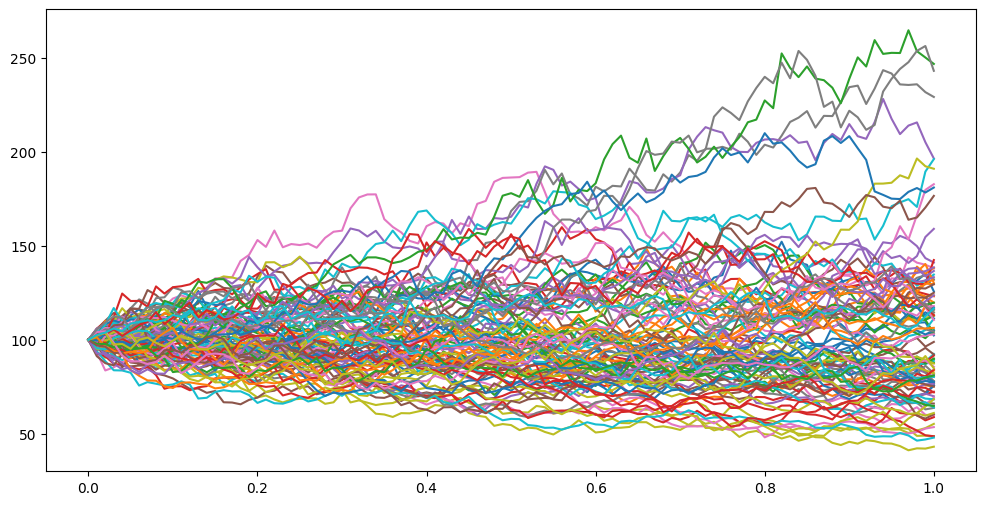

In [48]:
import matplotlib.pyplot as plt

plt.figure(1)
plt.figure(figsize= (12, 6))
plt.plot(paths['time'], np.transpose(paths['S']))
plt.show()

# plt.figure(2)
# plt.figure(figsize= (12, 6))
# plt.plot(paths_6m['time'], np.transpose(paths_6m['S']))
# # plt.plot(p['e'])
# plt.show()

In [65]:
def option_price(S_0, r, T, sigma, K, type, no_paths= 100000):

  paths = GBM(S_0, r, T, sigma, no_paths)
  S_T = paths['S'][:, -1]

  if type == 'call':
    payoff = np.maximum(S_T - K, 0)

  elif type == 'put':
    payoff = np.maximum(K - S_T, 0)

  else:
    raise ValueError(f"type must be 'call' or 'put', got '{type}'")

  return np.exp(-r*T) * np.mean(payoff)

In [66]:
c = option_price(S_0, r, T, sigma, K, type= 'call')
c

np.float64(11.77469451418374)

In [57]:
from scipy.stats import norm


def BlackSchole(S, r, T, K, sigma, type):

  d_1 = (np.log(S/K) + (r - sigma**2 * 0.5) * T) / (sigma * np.sqrt(T))
  d_2 = d_1 - (sigma * np.sqrt(T))

  if type == 'call':
    payoff = S * norm.cdf(d_1) - K * np.exp(-r * T) * norm.cdf(d_2)

  elif type == 'put':
    payoff = K * np.exp(-r * T) * norm.cdf(-d_2) - S * norm.cdf(-d_1)

  else:
    raise ValueError(f"type must be 'call' or 'put', got '{type}'")

  return payoff

In [58]:
BlackSchole(S_0, r, T, K, sigma, 'call')

np.float64(11.013725401222779)